# HOUR 4: UNSUPERVISED LEARNING (60 mins)

## ALGORITHM 1: K-MEANS CLUSTERING

### Definition
K-Means divides data into **K distinct clusters** based on similarity. Each data point belongs to the cluster with the nearest **centroid** (center point).

### Indian Analogy: Dividing Students for School Houses 🏫
```
Step 1: Choose K=4 (Red, Blue, Green, Yellow houses)
Step 2: Randomly pick 4 students as initial "House Captains" (centroids)
Step 3: Each student joins the house whose captain they're most similar to
        (in terms of sports, academics, leadership scores)
Step 4: Calculate new "average student" for each house (new centroid)
Step 5: Reassign students based on new averages
Step 6: Repeat until no one changes houses

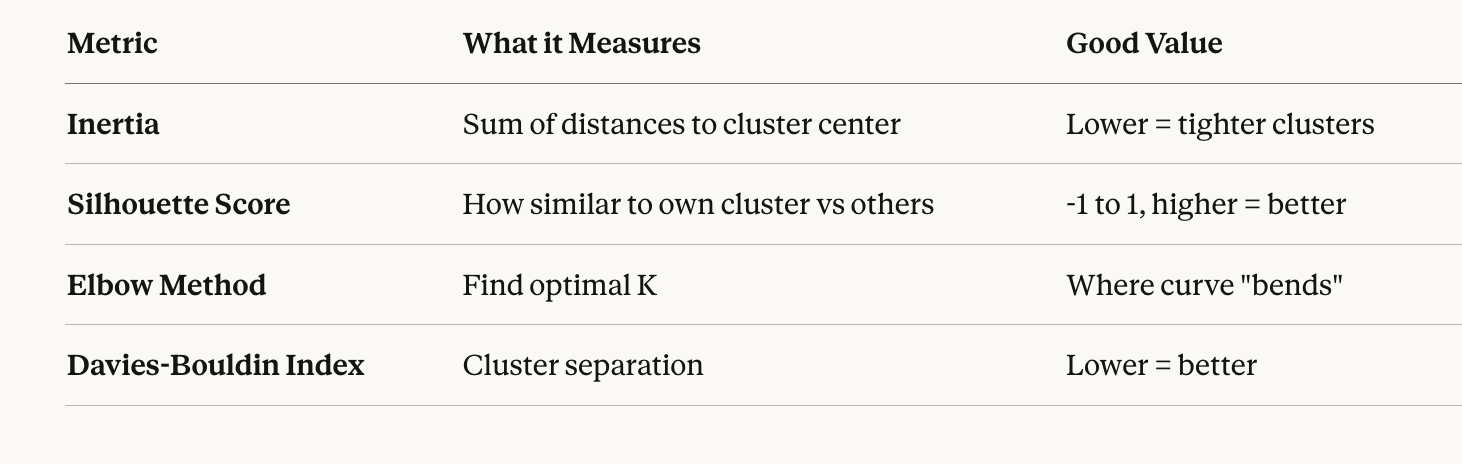

In [19]:
# ============================================================
# K-MEANS CLUSTERING - COMPLETE WITH EVALUATION
# ============================================================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create Dataset - E-commerce Customer Segmentation
np.random.seed(42)
n_customers = 500

customer_data = {
    'annual_income_lakhs': np.concatenate([
        np.random.normal(5, 1.5, 150),    # Low income
        np.random.normal(15, 3, 200),     # Middle income
        np.random.normal(35, 5, 150)      # High income
    ]),
    'spending_score': np.concatenate([
        np.random.normal(30, 10, 150),    # Low spenders
        np.random.normal(50, 15, 200),    # Medium spenders
        np.random.normal(80, 10, 150)     # High spenders
    ]),
    'age': np.random.randint(18, 65, n_customers),
    'purchase_frequency': np.random.randint(1, 30, n_customers),
}
df = pd.DataFrame(customer_data)
df['annual_income_lakhs'] = df['annual_income_lakhs'].clip(lower=2)
df['spending_score'] = df['spending_score'].clip(1, 100)

print("=== Customer Data for Segmentation ===")
print(df.head(10))
print(f"\nDataset Shape: {df.shape}")
print(f"\nStatistics:\n{df.describe()}")

=== Customer Data for Segmentation ===
   annual_income_lakhs  spending_score  age  purchase_frequency
0             5.745071       39.261775   61                  25
1             4.792604       49.094166   57                  23
2             5.971533       16.014324   28                  16
3             7.284545       35.629692   20                  12
4             4.648770       23.493574   23                  17
5             4.648795       25.128746   26                  16
6             7.368819       24.076061   23                  12
7             6.151152       21.360092   26                   8
8             4.295788       30.485216   56                  20
9             5.813840       21.690499   48                   3

Dataset Shape: (500, 4)

Statistics:
       annual_income_lakhs  spending_score        age  purchase_frequency
count           500.000000      500.000000  500.00000          500.000000
mean             18.073318       53.366955   40.87200           14.9860

In [20]:
# Feature Scaling (CRITICAL for K-Means!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled

array([[-0.99134438, -0.60079216,  1.44184115,  1.20843886],
       [-1.06793462, -0.18199397,  1.15530674,  0.96708898],
       [-0.97313405, -1.59098777, -0.92206773,  0.12236439],
       ...,
       [ 1.28458772,  1.40735955, -0.56389972, -0.48101032],
       [ 1.00906272,  0.89111427,  1.29857395,  0.12236439],
       [ 0.80514423,  1.37828504,  0.43897072,  0.48438921]],
      shape=(500, 4))


STEP 1: FINDING OPTIMAL NUMBER OF CLUSTERS (K)
K=2: Inertia=1277.54, Silhouette=0.3469
K=3: Inertia=1005.42, Silhouette=0.2912
K=4: Inertia=839.97, Silhouette=0.2913
K=5: Inertia=717.40, Silhouette=0.2773
K=6: Inertia=623.04, Silhouette=0.2756
K=7: Inertia=559.18, Silhouette=0.2763
K=8: Inertia=500.99, Silhouette=0.2850
K=9: Inertia=455.49, Silhouette=0.2883
K=10: Inertia=420.08, Silhouette=0.2836


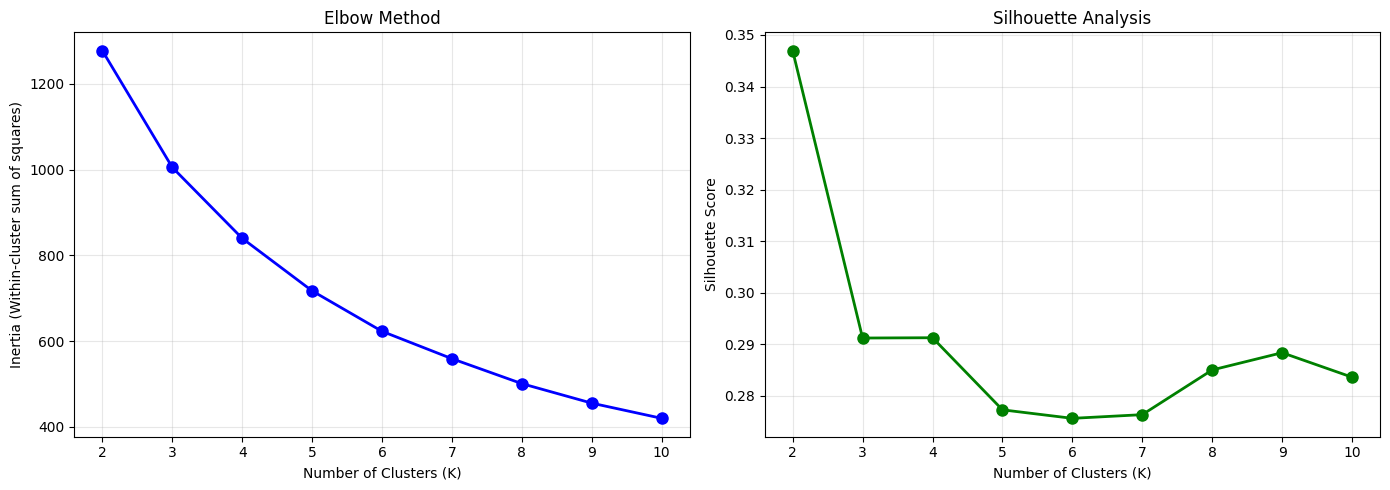


✅ Optimal K based on Silhouette Score: 2


In [21]:
# === STEP 1: FIND OPTIMAL K (Elbow Method) ===
print(f"\n{'='*60}")
print("STEP 1: FINDING OPTIMAL NUMBER OF CLUSTERS (K)")
print(f"{'='*60}")

inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, kmeans.labels_))
    print(f"K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={silhouettes[-1]:.4f}")

# Plot Elbow and Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Plot
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-cluster sum of squares)')
axes[0].set_title('Elbow Method')
axes[0].grid(True, alpha=0.3)

# Silhouette Plot
axes[1].plot(K_range, silhouettes, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kmeans_optimal_k.png', dpi=150)
plt.show()

optimal_k = K_range[np.argmax(silhouettes)]
print(f"\n✅ Optimal K based on Silhouette Score: {optimal_k}")

In [22]:
# === STEP 2: TRAIN FINAL MODEL ===
print(f"\n{'='*60}")
print(f"STEP 2: TRAINING K-MEANS WITH K={optimal_k}")
print(f"{'='*60}")

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(f"\nCluster Distribution:")
print(df['cluster'].value_counts().sort_index())


STEP 2: TRAINING K-MEANS WITH K=2

Cluster Distribution:
cluster
0    336
1    164
Name: count, dtype: int64


In [23]:
# === STEP 3: EVALUATION METRICS ===
print(f"\n{'='*60}")
print("STEP 3: CLUSTERING EVALUATION METRICS")
print(f"{'='*60}")

silhouette = silhouette_score(X_scaled, df['cluster'])
davies_bouldin = davies_bouldin_score(X_scaled, df['cluster'])
calinski = calinski_harabasz_score(X_scaled, df['cluster'])

print(f"\nSilhouette Score: {silhouette:.4f}")
print(f"  → Range: -1 to 1, Higher is better")
print(f"  → Interpretation: {'Excellent' if silhouette > 0.5 else 'Good' if silhouette > 0.25 else 'Weak'} cluster separation")

print(f"\nDavies-Bouldin Index: {davies_bouldin:.4f}")
print(f"  → Lower is better (0 = perfect)")

print(f"\nCalinski-Harabasz Score: {calinski:.2f}")
print(f"  → Higher is better")

print(f"\nInertia (WCSS): {kmeans.inertia_:.2f}")


STEP 3: CLUSTERING EVALUATION METRICS

Silhouette Score: 0.3469
  → Range: -1 to 1, Higher is better
  → Interpretation: Good cluster separation

Davies-Bouldin Index: 1.1831
  → Lower is better (0 = perfect)

Calinski-Harabasz Score: 281.62
  → Higher is better

Inertia (WCSS): 1277.54


In [24]:
# === STEP 4: CLUSTER ANALYSIS ===
print(f"\n{'='*60}")
print("STEP 4: CLUSTER PROFILING")
print(f"{'='*60}")

cluster_profile = df.groupby('cluster').agg({
    'annual_income_lakhs': ['mean', 'std', 'count'],
    'spending_score': ['mean', 'std'],
    'age': ['mean', 'std'],
    'purchase_frequency': ['mean', 'std']
}).round(2)

print("\nCluster Profiles:")
print(cluster_profile)

# Name the clusters
print("\n=== CUSTOMER SEGMENTS ===")
for cluster in range(optimal_k):
    cluster_data = df[df['cluster'] == cluster]
    avg_income = cluster_data['annual_income_lakhs'].mean()
    avg_spending = cluster_data['spending_score'].mean()
    count = len(cluster_data)
    
    # Determine segment name
    if avg_income < 10 and avg_spending < 40:
        segment = "Budget Conscious 💰"
    elif avg_income > 25 and avg_spending > 70:
        segment = "Premium Customers 👑"
    elif avg_spending > 60:
        segment = "High Value Seekers 🎯"
    else:
        segment = "Regular Customers 🛒"
    
    print(f"\nCluster {cluster}: {segment}")
    print(f"  Count: {count} customers ({count/len(df)*100:.1f}%)")
    print(f"  Avg Income: ₹{avg_income:.1f} Lakhs")
    print(f"  Avg Spending Score: {avg_spending:.1f}")
    print(f"  Avg Age: {cluster_data['age'].mean():.1f} years")


STEP 4: CLUSTER PROFILING

Cluster Profiles:
        annual_income_lakhs             spending_score           age         \
                       mean   std count           mean    std   mean    std   
cluster                                                                       
0                     10.45  5.47   336          40.01  15.23  41.19  13.92   
1                     33.69  6.91   164          80.74   9.59  40.23  14.10   

        purchase_frequency        
                      mean   std  
cluster                           
0                    14.39  8.42  
1                    16.21  7.91  

=== CUSTOMER SEGMENTS ===

Cluster 0: Regular Customers 🛒
  Count: 336 customers (67.2%)
  Avg Income: ₹10.5 Lakhs
  Avg Spending Score: 40.0
  Avg Age: 41.2 years

Cluster 1: Premium Customers 👑
  Count: 164 customers (32.8%)
  Avg Income: ₹33.7 Lakhs
  Avg Spending Score: 80.7
  Avg Age: 40.2 years


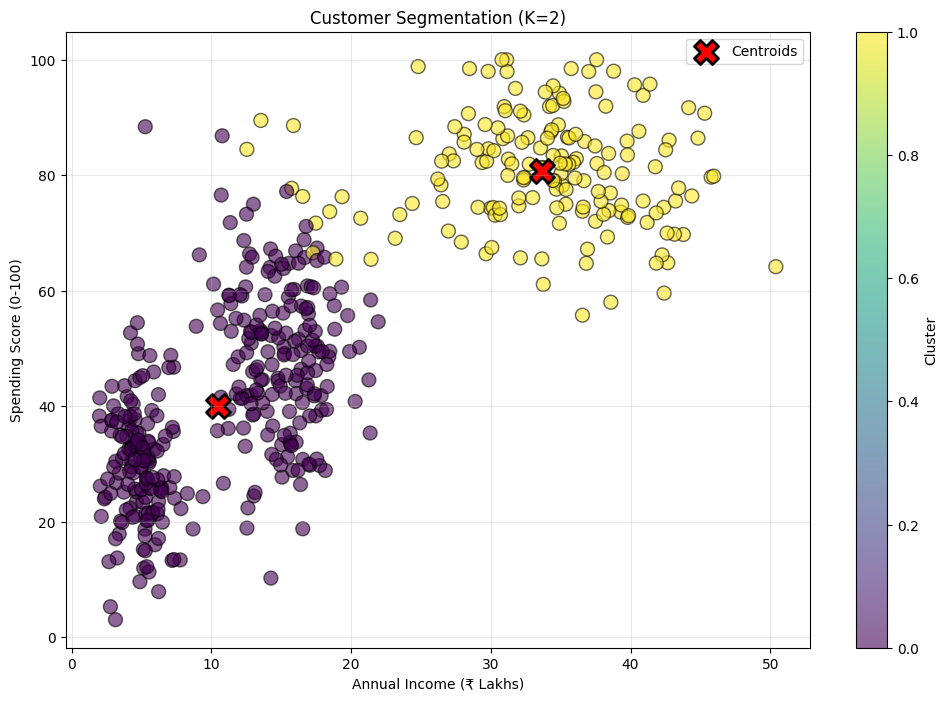

In [25]:
# === STEP 5: VISUALIZATION ===
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df['annual_income_lakhs'], df['spending_score'], 
                     c=df['cluster'], cmap='viridis', s=100, alpha=0.6, edgecolors='black')

# Plot centroids (in original scale)
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids_original[:, 0], centroids_original[:, 1], 
           c='red', marker='X', s=300, edgecolors='black', linewidths=2, label='Centroids')

plt.xlabel('Annual Income (₹ Lakhs)')
plt.ylabel('Spending Score (0-100)')
plt.title(f'Customer Segmentation (K={optimal_k})')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('customer_segments.png', dpi=150)
plt.show()


In [26]:
# === STEP 6: PREDICT FOR NEW CUSTOMER ===
print(f"\n{'='*60}")
print("STEP 6: ASSIGN NEW CUSTOMER TO SEGMENT")
print(f"{'='*60}")

new_customer = pd.DataFrame({
    'annual_income_lakhs': [20],
    'spending_score': [75],
    'age': [35],
    'purchase_frequency': [15]
})

new_scaled = scaler.transform(new_customer)
predicted_cluster = kmeans.predict(new_scaled)[0]

print(f"\nNew Customer Profile:")
print(f"  Income: ₹20 Lakhs")
print(f"  Spending Score: 75")
print(f"  Age: 35")
print(f"  Purchase Frequency: 15/month")
print(f"\n🎯 Assigned to Cluster: {predicted_cluster}")
print(f"   Marketing Strategy: Target with premium offers!")


STEP 6: ASSIGN NEW CUSTOMER TO SEGMENT

New Customer Profile:
  Income: ₹20 Lakhs
  Spending Score: 75
  Age: 35
  Purchase Frequency: 15/month

🎯 Assigned to Cluster: 1
   Marketing Strategy: Target with premium offers!


In [30]:
# IPL teams clustered by playing style
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import pandas as pd

# Team statistics
ipl_data = {
    'team': ['MI', 'CSK', 'RCB', 'KKR', 'DC', 'RR', 'PBKS', 'SRH'],
    'avg_powerplay_score': [52, 45, 55, 48, 50, 46, 54, 42],
    'boundary_percentage': [65, 55, 70, 58, 62, 56, 68, 52],
    'death_bowling_economy': [8.5, 7.8, 9.2, 8.0, 8.3, 8.1, 9.0, 7.5],
    'middle_over_run_rate': [7.8, 7.2, 8.5, 7.5, 7.9, 7.3, 8.2, 7.0]
}
df = pd.DataFrame(ipl_data)

# Prepare features
X = df[['avg_powerplay_score', 'boundary_percentage', 'death_bowling_economy', 'middle_over_run_rate']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Find optimal K
scores = []
for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    scores.append(silhouette_score(X_scaled, kmeans.labels_))
    
optimal_k = range(2, 6)[scores.index(max(scores))]
print(f"Optimal clusters: {optimal_k}")

# Train with optimal K
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['playing_style'] = kmeans.fit_predict(X_scaled)

# Evaluation
print(f"\nSilhouette Score: {silhouette_score(X_scaled, df['playing_style']):.4f}")

# Results
style_names = {0: 'Aggressive 💥', 1: 'Balanced ⚖️', 2: 'Defensive 🛡️'}
print(f"\n=== IPL TEAM PLAYING STYLES ===")
for _, row in df.iterrows():
    print(f"{row['team']}: {style_names.get(row['playing_style'], f'Style {row["playing_style"]}')}")


Optimal clusters: 2

Silhouette Score: 0.5563

=== IPL TEAM PLAYING STYLES ===
MI: Aggressive 💥
CSK: Balanced ⚖️
RCB: Aggressive 💥
KKR: Balanced ⚖️
DC: Aggressive 💥
RR: Balanced ⚖️
PBKS: Aggressive 💥
SRH: Balanced ⚖️
